# Chem Data Experiments

In [1]:
# Import necessary packages and libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp
import graphlearning as gl
from scipy.special import jn
import scipy.sparse as sps
import scipy.sparse.linalg as spla
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.ndimage import gaussian_filter
from itertools import product
from joblib import Parallel, delayed
from scipy.optimize import nnls
from sklearn.decomposition import PCA

# Import functions from Chen et. al.
from graph_active_learning_functions import *

## CuSO4 (exponentially distributed)

### Load data

In [23]:
samples = 1000
iters = 150
X_chem, S_gt_chem, A_gt_chem = load_data(name = 'synth_chem_data.npy', typename = 'chem')

Keys in the dataset: dict_keys(['X', 'A_gt', 'S_gt'])
Shape of X (Chemistry Sample): (1000, 1000)
Shape of A_gt (Abundance Map): (2, 1000)
Shape of S_gt (Endmember Spectra): (1000, 2)

First chemical's concentration in X (how much of class 1?):
 1.1670295769786863
<class 'numpy.ndarray'>
(1000, 2)
float64
<class 'numpy.ndarray'>
(2, 1000)
float64
Shape of X: (1000, 1000)


### Quick param testing

In [ ]:
# GLU

# Best RMSE + SAD: 42.508042837023396
# Best alpha: 100
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01

alpha_vals = np.array([10, 20, 50, 100])
lam_vals = np.sort(np.concatenate([10**np.arange(4), 5 * 10**np.arange(4)]))
gamma_vals = 10.0 ** np.arange(-2, 3)
rho_vals = 10.0 ** np.arange(-2, 3)

parameter_testing(X = X_chem, A_gt = A_gt_chem, S_gt = S_gt_chem, N = samples, 
                  iters = iters, alpha = alpha_vals, lam = lam_vals, gamma = gamma_vals, rho = rho_vals, m_0 = 2, 
                  print_bool = False, GRSU_bool = False, OH_labels = True)

Best RMSE + SAD: 42.508042837023396
Best alpha: 100
Best lambda: 1
Best gamma: 0.01
Best rho: 0.01


[np.int64(100), np.int64(1), np.float64(0.01), np.float64(0.01)]

In [ ]:
# GRSU (OH)

# Best RMSE + SAD: 31.676199839969286
# Best alpha: 10
# Best lambda: 5000
# Best gamma: 0.01
# Best rho: 1.0

alpha_vals = np.array([10, 20, 50, 100])
lam_vals = np.sort(np.concatenate([10**np.arange(4), 5 * 10**np.arange(4)]))
gamma_vals = 10.0 ** np.arange(-2, 3)
rho_vals = 10.0 ** np.arange(-2, 3)

parameter_testing(X = X_chem, A_gt = A_gt_chem, S_gt = S_gt_chem, N = samples, 
                  iters = iters, alpha = alpha_vals, lam = lam_vals, gamma = gamma_vals, rho = rho_vals, m_0 = 2, 
                  print_bool = False, GRSU_bool = True, OH_labels = True)

Best RMSE + SAD: 31.676199839969286
Best alpha: 10
Best lambda: 5000
Best gamma: 0.01
Best rho: 1.0


[np.int64(10), np.int64(5000), np.float64(0.01), np.float64(1.0)]

In [ ]:
# GRSU (Exact)

# Best RMSE + SAD: 33.45297231889466
# Best alpha: 10
# Best lambda: 5000
# Best gamma: 0.01
# Best rho: 10.0

alpha_vals = np.array([10, 20, 50, 100])
lam_vals = np.sort(np.concatenate([10**np.arange(4), 5 * 10**np.arange(4)]))
gamma_vals = 10.0 ** np.arange(-2, 3)
rho_vals = 10.0 ** np.arange(-2, 3)

parameter_testing(X = X_chem, A_gt = A_gt_chem, S_gt = S_gt_chem, N = samples, 
                  iters = iters, alpha = alpha_vals, lam = lam_vals, gamma = gamma_vals, rho = rho_vals, m_0 = 2, 
                  print_bool = False, GRSU_bool = True, OH_labels = False)

Best RMSE + SAD: 33.45297231889466
Best alpha: 10
Best lambda: 5000
Best gamma: 0.01
Best rho: 10.0


[np.int64(10), np.int64(5000), np.float64(0.01), np.float64(10.0)]

### Algorithm (OH)

In [24]:
# GLU

# Best RMSE + SAD: 42.508042837023396
# Best alpha: 100
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01

A_GLU_chem, S_GLU_chem, A_GLU_RMSE_chem, S_GLU_RMSE_chem = run_unmixing_pipeline_example(X = X_chem, A_gt = A_gt_chem, S_gt = S_gt_chem, 
                                                                                         N = 1000, iters = iters, alpha = 100.0, lam = 1.0, gamma = 0.01, rho = 0.01, m_0 = 2, 
                                                                                         print_bool = True, OH_labels = True, GRSU_bool = False, 
                                                                                         A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "GLU on Chem Data (OH)", prep = None)

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GLU Unmixing on OH...
Pipeline Complete!

Final Abundance Map Shape: (2, 1000)
Final End-member Matrix Shape: (1000, 2)
Final Abundance RMSE: 13.959363249957091
Final Endmember SAD: 28.548679742458894


Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GRSU (and GLU) Unmixing on OH...


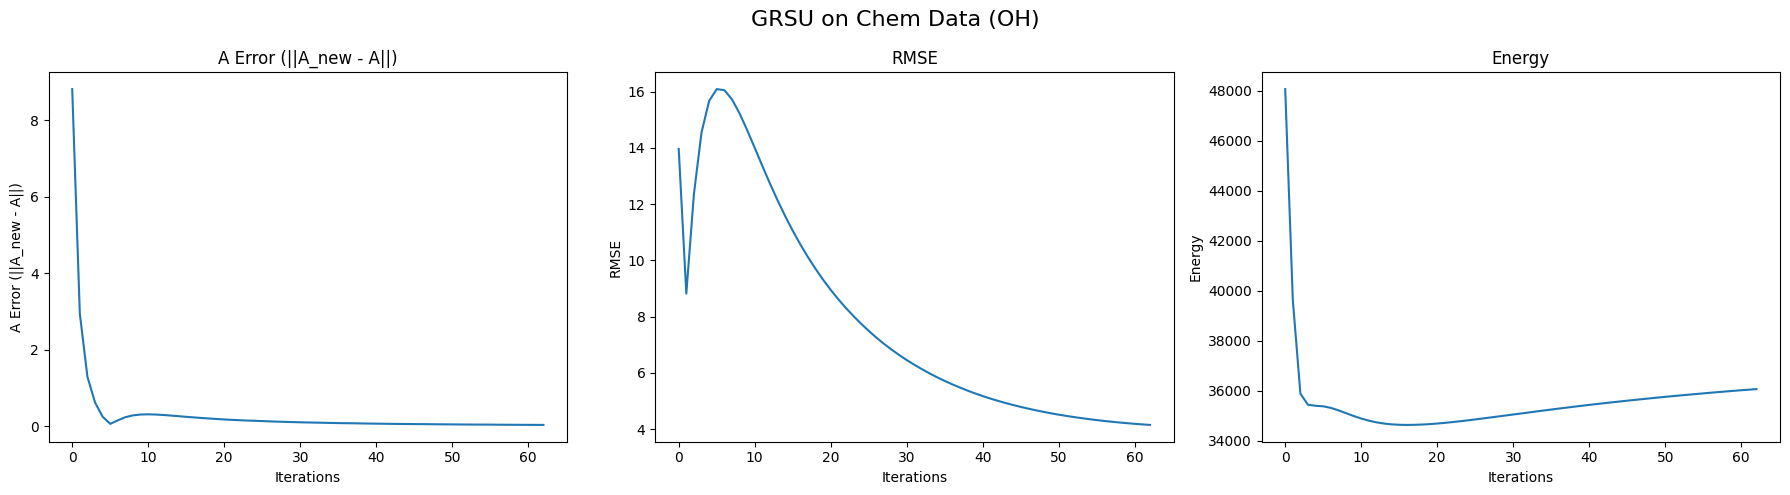

Pipeline Complete!

Final Abundance Map Shape: (2, 1000)
Final End-member Matrix Shape: (1000, 2)
Final Abundance RMSE: 4.130876933738816
Final Endmember SAD: 27.294019202418557


In [25]:
# GRSU

# Best RMSE + SAD: 31.676199839969286
# Best alpha: 10
# Best lambda: 5000
# Best gamma: 0.01
# Best rho: 1.0

A_GRSU_chem, S_GRSU_chem, A_GRSU_RMSE_chem, S_GRSU_RMSE_chem = run_unmixing_pipeline_example(X = X_chem, A_gt = A_gt_chem, S_gt = S_gt_chem, 
                                                                                         N = 1000, iters = iters, alpha = 10.0, lam = 5000.0, gamma = 0.01, rho = 1.0, m_0 = 2, 
                                                                                         print_bool = True, OH_labels = True, GRSU_bool = True, 
                                                                                         A_error = True, RMSE_plot = True, Energy_plot = True, title_0 = "GRSU on Chem Data (OH)", prep = None)

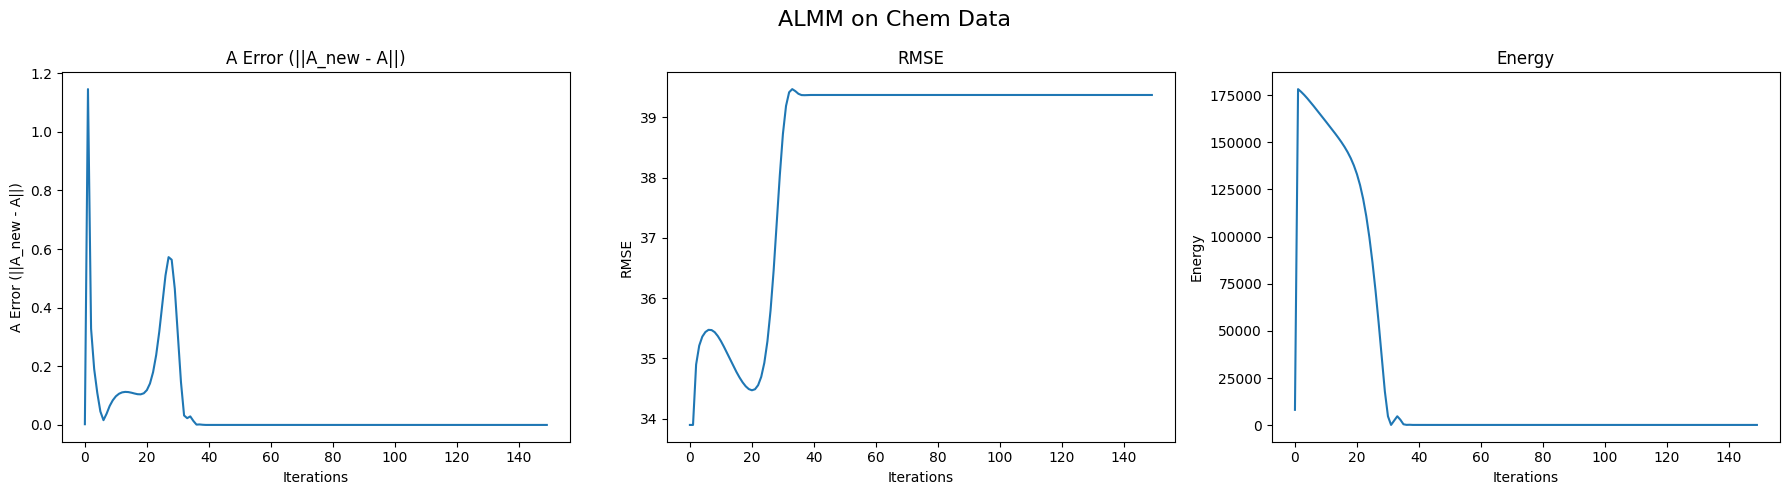

In [26]:
# ALMM

# Best RMSE: 39.372787527055124
# Best alpha: 5.4999999999999995e-05
# Best beta: 5.499999999999999e-07
# Best gamma: 5.499999999999999e-07
# Best eta: 5.499999999999999e-07

best_alpha = 5.5e-5
best_beta = 5.5e-7
best_gamma = 5.5e-7
best_eta = 5.5e-7

E_ALMM_chem, A_ALMM_chem, T_ALMM_chem, B_ALMM_chem = algo_2_almm_optimized(X = X_chem, S = S_gt_chem, A_gt = A_gt_chem, 
                                                                            alpha = best_alpha, beta = best_beta, gamma = best_gamma, eta = best_eta, 
                                                                            maxIter = iters,
                                                                            A_error = True, RMSE_plot = True, Energy_plot = True, title_0 = "ALMM on Chem Data")

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running ALMM (and GLU) Unmixing on OH...


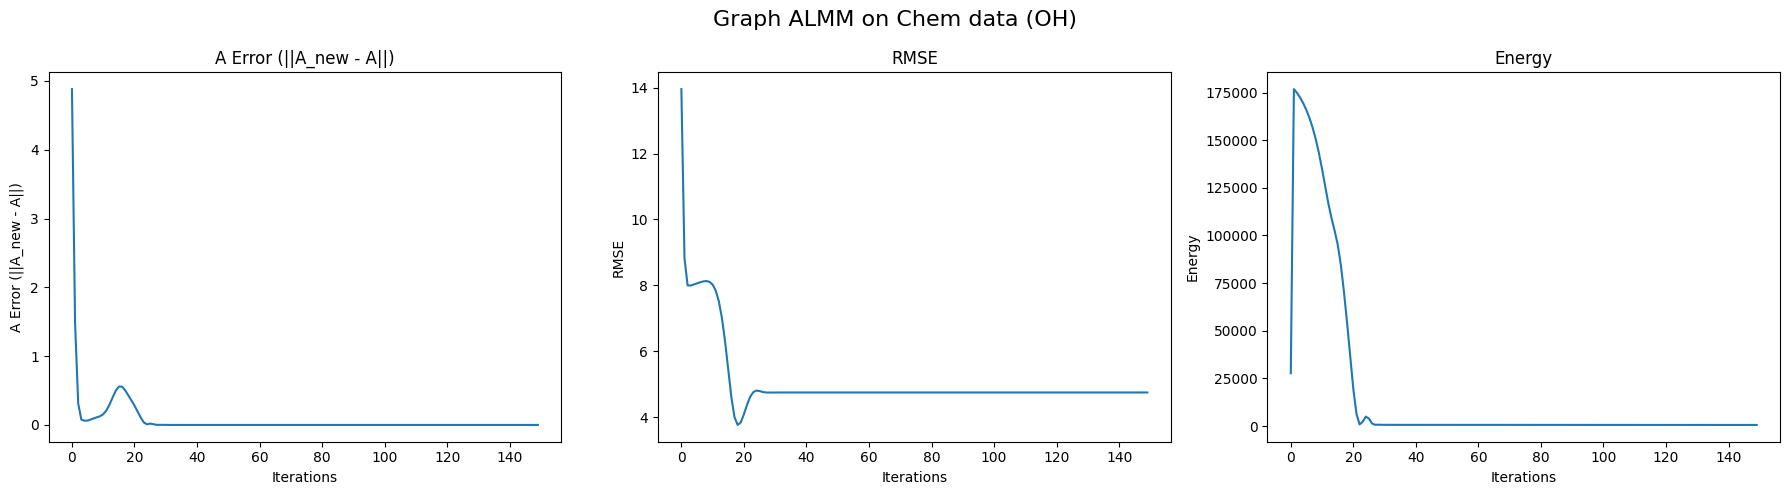

Pipeline Complete!

Final Abundance Map Shape: (2, 1000)
Final End-member Matrix Shape: (1000, 2)
Final Abundance RMSE: 4.746263674246179
Final Endmember SAD: 31.74438541019793


In [27]:
# Graph ALMM

# Best RMSE: 4.746085801511586
# Best alpha: 5.499999999999999e-07
# Best M_total: 4.0 (j = 1 here)
# Best xi: 0.1
# Best OH label: OH

alpha_0 = 5.5e-7
beta_0 = (1e-3 + 1e-2)/2
gamma_0 = (1e-3 + 1e-2)/2
eta_0 = (1e-3 + 1e-2)/2
xi_0 = 1e-1

A_graph_almm_chem, S_graph_almm_chem, A_rmse_graph_almm_chem, S_rmse_graph_almm_chem = run_unmixing_pipeline_example2(X = X_chem, A_gt = A_gt_chem, S_gt = S_gt_chem, N = samples, 
                                                                                                                        alpha = alpha_0, beta = beta_0, gamma = gamma_0, eta = eta_0, maxIter = iters, 
                                                                                                                        M_total_0 = 4, m_0 = 2, xi_0 = xi_0, 
                                                                                                                        OH_labels = True, print_bool = True, 
                                                                                                                        A_error = True, RMSE_plot = True, Energy_plot = True, title_0 = "Graph ALMM on Chem data (OH)")

### Abundance Plot

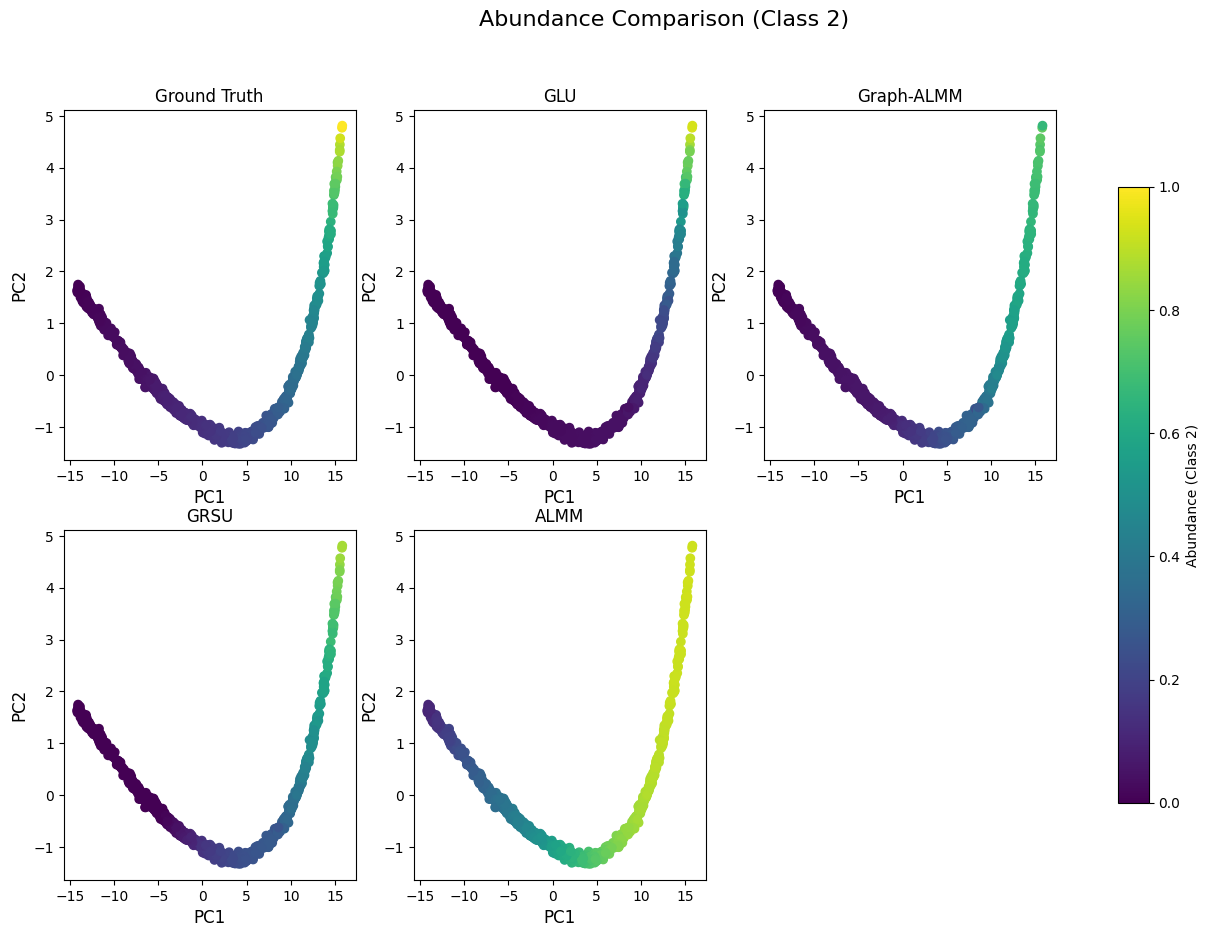

In [28]:
abundance_plotting(X = X_chem, A_gt = A_gt_chem, 
                   A_f_GLU = A_GLU_chem, A_f_GRSU = A_GRSU_chem, A_f_ALMM = A_ALMM_chem, A_f_Graph_ALMM = A_graph_almm_chem, 
                   title = 'Abundance Comparison (Class 2)', color_title = 'Abundance (Class 2)')

## FeSO4

### Load data

In [2]:
samples = 1000
iters = 100
X_chem_FeSO4, S_gt_chem_FeSO4, A_gt_chem_FeSO4 = load_data(name = 'synth_FeSO4_data.npy', typename = 'chem')

Keys in the dataset: dict_keys(['X', 'A_gt', 'S_gt'])
Shape of X (Chemistry Sample): (1050, 1000)
Shape of A_gt (Abundance Map): (2, 1000)
Shape of S_gt (Endmember Spectra): (1050, 2)

First chemical's concentration in X (how much of class 1?):
 3.197846563216461
<class 'numpy.ndarray'>
(1050, 2)
float64
<class 'numpy.ndarray'>
(2, 1000)
float64
Shape of X: (1050, 1000)


### Quick param testing

In [62]:
# GLU

# Best RMSE + SAD: 12.437524085482382
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01

alpha_vals = np.array([10, 20, 50, 100])
lam_vals = np.sort(np.concatenate([10**np.arange(4), 5 * 10**np.arange(4)]))
gamma_vals = 10.0 ** np.arange(-2, 3)
rho_vals = 10.0 ** np.arange(-2, 3)

parameter_testing(X = X_chem_FeSO4, A_gt = A_gt_chem_FeSO4, S_gt = S_gt_chem_FeSO4, N = samples, 
                  iters = iters, alpha = alpha_vals, lam = lam_vals, gamma = gamma_vals, rho = rho_vals, m_0 = 2, 
                  print_bool = False, GRSU_bool = False, OH_labels = True)

Best RMSE + SAD: 12.437524085482382
Best alpha: 10
Best lambda: 1
Best gamma: 0.01
Best rho: 0.01


[np.int64(10), np.int64(1), np.float64(0.01), np.float64(0.01)]

In [63]:
# GRSU (OH)

# Best RMSE + SAD: 6.9817391724121745
# Best alpha: 10
# Best lambda: 5000
# Best gamma: 10.0
# Best rho: 1.0

alpha_vals = np.array([10, 20, 50, 100])
lam_vals = np.sort(np.concatenate([10**np.arange(4), 5 * 10**np.arange(4)]))
gamma_vals = 10.0 ** np.arange(-2, 3)
rho_vals = 10.0 ** np.arange(-2, 3)

parameter_testing(X = X_chem_FeSO4, A_gt = A_gt_chem_FeSO4, S_gt = S_gt_chem_FeSO4, N = samples, 
                  iters = iters, alpha = alpha_vals, lam = lam_vals, gamma = gamma_vals, rho = rho_vals, m_0 = 2, 
                  print_bool = False, GRSU_bool = True, OH_labels = True)

Best RMSE + SAD: 6.9817391724121745
Best alpha: 10
Best lambda: 5000
Best gamma: 10.0
Best rho: 1.0


[np.int64(10), np.int64(5000), np.float64(10.0), np.float64(1.0)]

### Algorithm (OH)

In [4]:
G, W = build_custom_knn_graph(X_chem_FeSO4.T, K=int(1000*0.005))
labeled_indices = algo_1_active_learning(X_chem_FeSO4, W, m_initial=2, M_total=int(0.004*1000), num_eigs=int(1000*0.005))
X_hat = X_chem_FeSO4[:, labeled_indices]
A_hat_exact = A_gt_chem_FeSO4[:, labeled_indices]
A_hat_OH = generate_one_hot_labels(A_hat_exact)
prep = [X_hat, A_hat_OH, "OH"]

print("Labeled indices:", labeled_indices)

Labeled indices: [np.int64(521), np.int64(737), np.int64(603), np.int64(993)]


In [9]:
# GLU

# Best RMSE + SAD: 12.437524085482382
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01

A_GLU_chem_FeSO4, S_GLU_chem_FeSO4, A_GLU_RMSE_chem_FeSO4, S_GLU_RMSE_chem_FeSO4 = run_unmixing_pipeline_example(X = X_chem_FeSO4, A_gt = A_gt_chem_FeSO4, S_gt = S_gt_chem_FeSO4, 
                                                                                         N = 1000, iters = iters, alpha = 100.0, lam = 1.0, gamma = 0.01, rho = 0.01, m_0 = 2, 
                                                                                         print_bool = True, OH_labels = True, GRSU_bool = False, 
                                                                                         A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "GLU on FeSO4 Chem Data (OH)", prep = None)

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GLU Unmixing on OH...
Pipeline Complete!

Final Abundance Map Shape: (2, 1000)
Final End-member Matrix Shape: (1050, 2)
Final Abundance RMSE: 8.571594956215181
Final Endmember SAD: 6.365888461246179


In [6]:
A_f, S_f, A_rmse, S_sad = run_unmixing_pipeline_example(
    X=X_chem_FeSO4, A_gt=A_gt_chem_FeSO4, S_gt=S_gt_chem_FeSO4,
    N=1000, iters=iters, alpha=100.0, lam=1.0, gamma=0.01, rho=0.01, m_0=2,
    print_bool=True, OH_labels=True, GRSU_bool=False,
    prep=prep)  # <-- using the exact same prep now

print(A_rmse + S_sad)

Running GLU Unmixing on OH...
Pipeline Complete!

Final Abundance Map Shape: (2, 1000)
Final End-member Matrix Shape: (1050, 2)
Final Abundance RMSE: 8.571594956215181
Final Endmember SAD: 6.365888461246179
14.93748341746136


In [12]:
result = Parallel(n_jobs=-1)(delayed(sum_RMSE_SAD)(X_chem_FeSO4, A_gt_chem_FeSO4, S_gt_chem_FeSO4, 1000, iters, 100.0, 1.0, 0.01, 0.01, 2, print_bool=True, OH_labels=True, GRSU_bool=False, prep=prep) for _ in range(1))
print(result)

Running GLU Unmixing on OH...
Pipeline Complete!

Final Abundance Map Shape: (2, 1000)
Final End-member Matrix Shape: (1050, 2)
Final Abundance RMSE: 8.571594948810716
Final Endmember SAD: 6.36588846124136
[np.float64(14.937483410052076)]


In [11]:
# At the very top of a test script
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import numpy as np
from joblib import Parallel, delayed

# Run your known-good manual comparison THROUGH parameter_testing's actual machinery
result = parameter_testing(
    X=X_chem_FeSO4, A_gt=A_gt_chem_FeSO4, S_gt=S_gt_chem_FeSO4, N=1000,
    iters=100, alpha=np.array([100]), lam=np.array([1.0]), gamma=np.array([0.01]), rho=np.array([0.01]),
    m_0=2, print_bool=True, GRSU_bool=False, OH_labels=True
)

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GLU Unmixing on OH...
Pipeline Complete!

Final Abundance Map Shape: (2, 1000)
Final End-member Matrix Shape: (1050, 2)
Final Abundance RMSE: 8.571594948810716
Final Endmember SAD: 6.36588846124136
Best RMSE + SAD: 14.937483410052076
Best alpha: 100
Best lambda: 1.0
Best gamma: 0.01
Best rho: 0.01


Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GRSU (and GLU) Unmixing on OH...


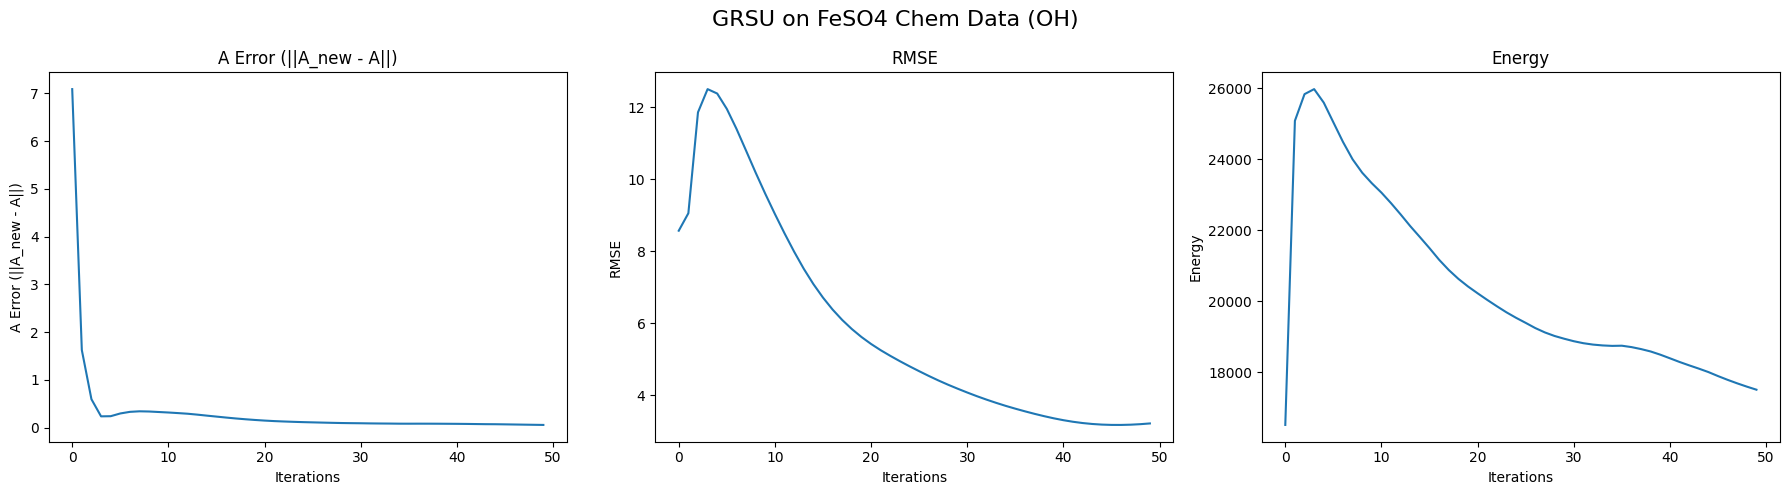

Pipeline Complete!

Final Abundance Map Shape: (2, 1000)
Final End-member Matrix Shape: (1050, 2)
Final Abundance RMSE: 3.249025612939783
Final Endmember SAD: 3.74509344938794


In [65]:
# GRSU

# Best RMSE + SAD: 6.9817391724121745
# Best alpha: 10
# Best lambda: 5000
# Best gamma: 10.0
# Best rho: 1.0

A_GRSU_chem_FeSO4, S_GRSU_chem_FeSO4, A_GRSU_RMSE_chem_FeSO4, S_GRSU_RMSE_chem_FeSO4 = run_unmixing_pipeline_example(X = X_chem_FeSO4, A_gt = A_gt_chem_FeSO4, S_gt = S_gt_chem_FeSO4, 
                                                                                         N = 1000, iters = iters, alpha = 10.0, lam = 5000.0, gamma = 0.01, rho = 1.0, m_0 = 2, 
                                                                                         print_bool = True, OH_labels = True, GRSU_bool = True, 
                                                                                         A_error = True, RMSE_plot = True, Energy_plot = True, title_0 = "GRSU on FeSO4 Chem Data (OH)", prep = None)

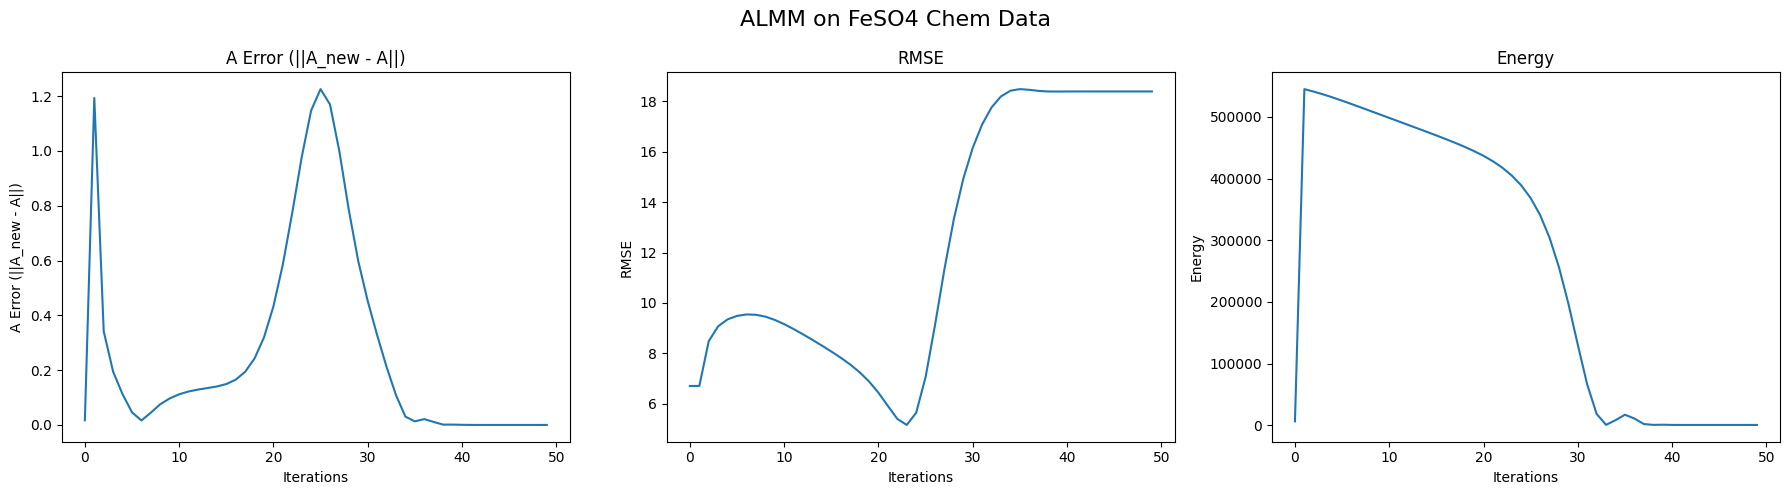

In [66]:
# ALMM (not tuned)

# Best RMSE: 39.372787527055124
# Best alpha: 5.4999999999999995e-05
# Best beta: 5.499999999999999e-07
# Best gamma: 5.499999999999999e-07
# Best eta: 5.499999999999999e-07

best_alpha = 5.5e-5
best_beta = 5.5e-7
best_gamma = 5.5e-7
best_eta = 5.5e-7

E_ALMM_chem_FeSO4, A_ALMM_chem_FeSO4, T_ALMM_chem_FeSO4, B_ALMM_chem_FeSO4 = algo_2_almm_optimized(X = X_chem_FeSO4, S = S_gt_chem_FeSO4, A_gt = A_gt_chem_FeSO4, 
                                                                            alpha = best_alpha, beta = best_beta, gamma = best_gamma, eta = best_eta, 
                                                                            maxIter = iters,
                                                                            A_error = True, RMSE_plot = True, Energy_plot = True, title_0 = "ALMM on FeSO4 Chem Data")

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running ALMM (and GLU) Unmixing on OH...


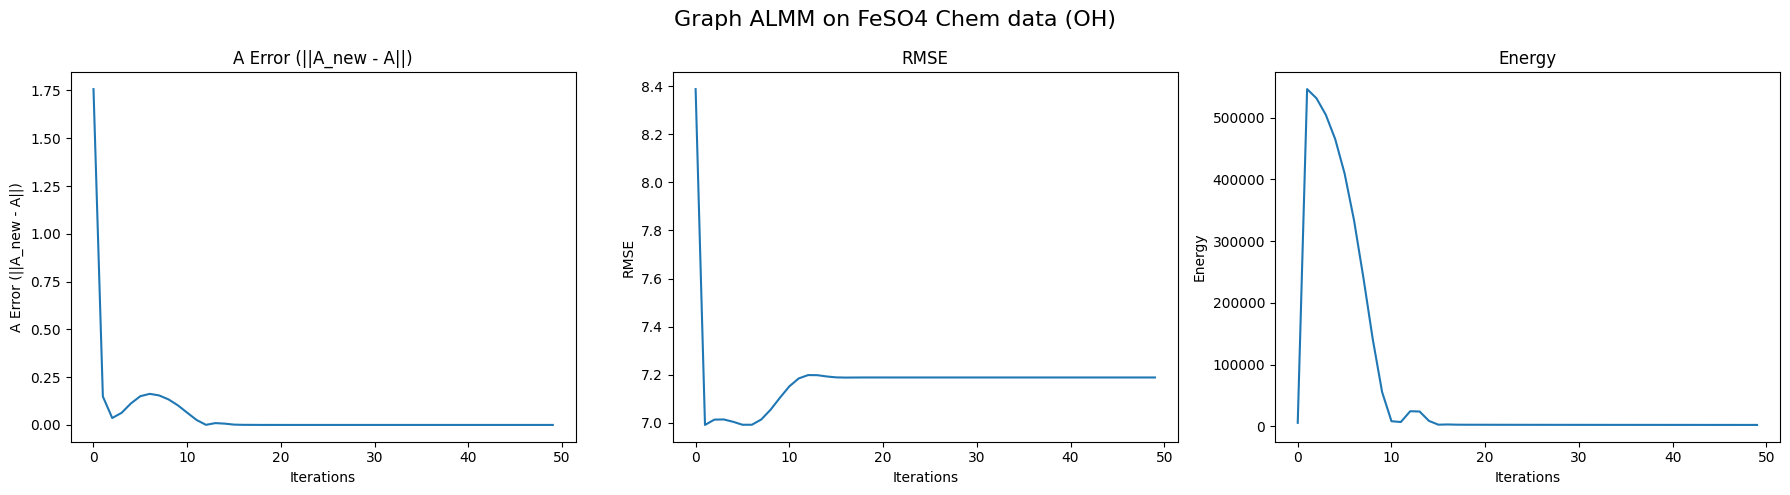

Pipeline Complete!

Final Abundance Map Shape: (2, 1000)
Final End-member Matrix Shape: (1050, 2)
Final Abundance RMSE: 7.188137410085499
Final Endmember SAD: 2.5630791707815304


In [67]:
# Graph ALMM (not tuned)

# Best RMSE: 4.746085801511586
# Best alpha: 5.499999999999999e-07
# Best M_total: 4.0 (j = 1 here)
# Best xi: 0.1
# Best OH label: OH

alpha_0 = 5.5e-7
beta_0 = (1e-3 + 1e-2)/2
gamma_0 = (1e-3 + 1e-2)/2
eta_0 = (1e-3 + 1e-2)/2
xi_0 = 10

A_graph_almm_chem_FeSO4, S_graph_almm_chem_FeSO4, A_rmse_graph_almm_chem_FeSO4, S_rmse_graph_almm_chem_FeSO4 = run_unmixing_pipeline_example2(X = X_chem_FeSO4, A_gt = A_gt_chem_FeSO4, S_gt = S_gt_chem_FeSO4, N = samples, 
                                                                                                                        alpha = alpha_0, beta = beta_0, gamma = gamma_0, eta = eta_0, maxIter = iters, 
                                                                                                                        M_total_0 = 8, m_0 = 2, xi_0 = xi_0, 
                                                                                                                        OH_labels = True, print_bool = True, 
                                                                                                                        A_error = True, RMSE_plot = True, Energy_plot = True, title_0 = "Graph ALMM on FeSO4 Chem data (OH)")

### Abundance plot

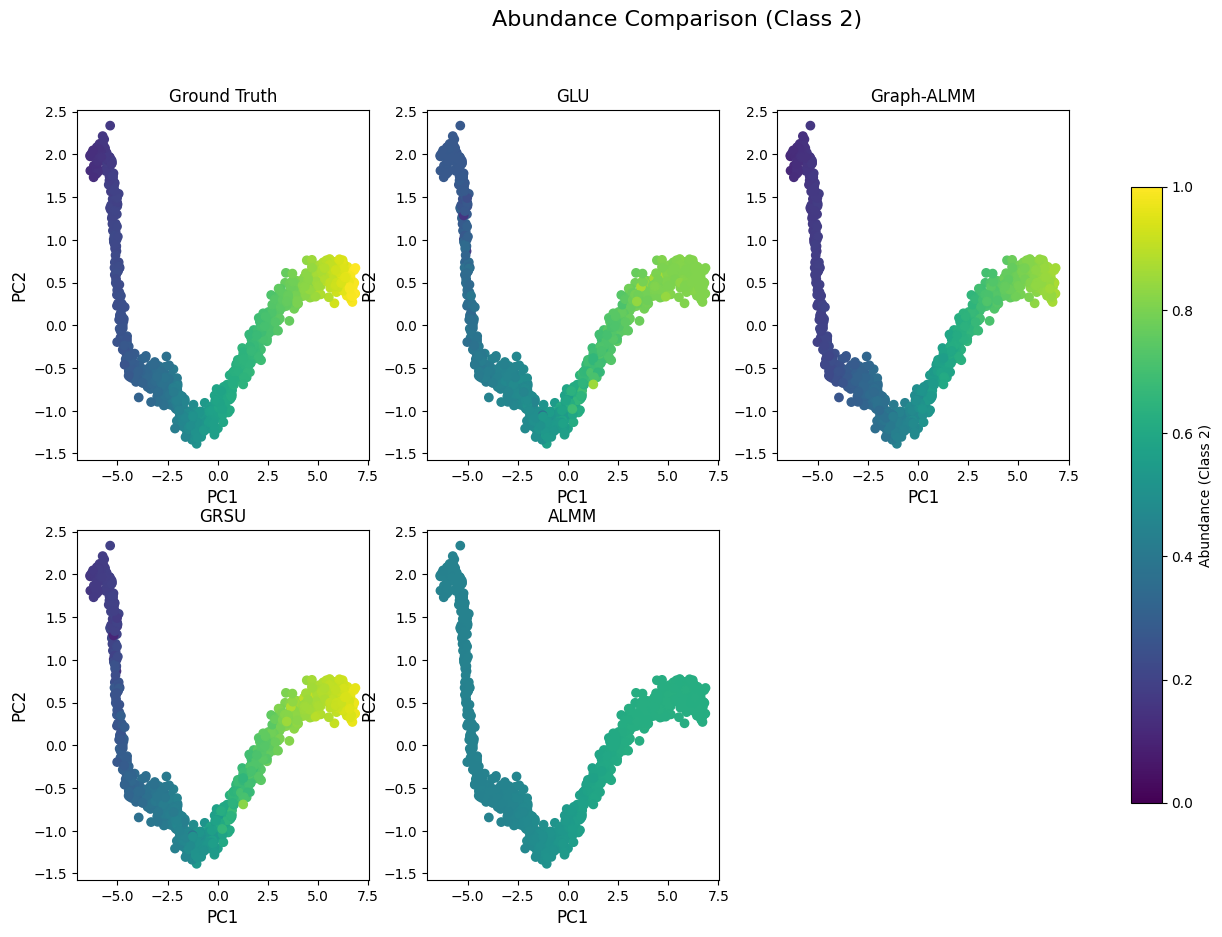

In [68]:
abundance_plotting(X = X_chem_FeSO4, A_gt = A_gt_chem_FeSO4, 
                   A_f_GLU = A_GLU_chem_FeSO4, A_f_GRSU = A_GRSU_chem_FeSO4, A_f_ALMM = A_ALMM_chem_FeSO4, A_f_Graph_ALMM = A_graph_almm_chem_FeSO4, 
                   title = 'Abundance Comparison (Class 2)', color_title = 'Abundance (Class 2)')

## CuSO4

### Load data

In [2]:
samples = 1000
iters = 100
X_chem_CuSO4, S_gt_chem_CuSO4, A_gt_chem_CuSO4 = load_data(name = 'synth_CuSO4_data.npy', typename = 'chem')

Keys in the dataset: dict_keys(['X', 'A_gt', 'S_gt'])
Shape of X (Chemistry Sample): (1050, 1000)
Shape of A_gt (Abundance Map): (2, 1000)
Shape of S_gt (Endmember Spectra): (1050, 2)

First chemical's concentration in X (how much of class 1?):
 1.138992504603515
<class 'numpy.ndarray'>
(1050, 2)
float64
<class 'numpy.ndarray'>
(2, 1000)
float64
Shape of X: (1050, 1000)


### Algorithm (OH)

In [3]:
A_GLU_CuSO4, S_GLU_CuSO4, A_GLU_RMSE_CuSO4, S_GLU_RMSE_CuSO4 = run_unmixing_pipeline_example(X = X_chem_CuSO4, A_gt = A_gt_chem_CuSO4, S_gt = S_gt_chem_CuSO4, 
                                                                                         N = 1000, iters = iters, alpha = 10.0, lam = 1.0, gamma = 0.01, rho = 0.01, m_0 = 2, 
                                                                                         print_bool = True, OH_labels = False, GRSU_bool = False, 
                                                                                         A_error = True, RMSE_plot = True, Energy_plot = True, title_0 = "GLU on CuSO4 Data (OH)", prep = None)

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GLU Unmixing on Exact...
Pipeline Complete!

Final Abundance Map Shape: (2, 1000)
Final End-member Matrix Shape: (1050, 2)
Final Abundance RMSE: 25.769248884342645
Final Endmember SAD: 33.286844166276815


## FeCI3

### Load data

In [70]:
samples = 1000
iters = 50
X_chem_FeCl3, S_gt_chem_FeCl3, A_gt_chem_FeCl3 = load_data(name = 'synth_FeCl3_data.npy', typename = 'chem')

Keys in the dataset: dict_keys(['X', 'A_gt', 'S_gt'])
Shape of X (Chemistry Sample): (1050, 1000)
Shape of A_gt (Abundance Map): (2, 1000)
Shape of S_gt (Endmember Spectra): (1050, 2)

First chemical's concentration in X (how much of class 1?):
 8.427712607186892
<class 'numpy.ndarray'>
(1050, 2)
float64
<class 'numpy.ndarray'>
(2, 1000)
float64
Shape of X: (1050, 1000)
